# ProfileMLP — train on Production1, test on Production2

Cross-replicate generalization check on `fit4functionaav9.csv` (this folder, see
`log_enrichment_histograms.ipynb` for the raw replicate histograms): train a `ProfileMLP`
(same architecture/training loop as `aav_viability_test/AAV9_profile_model.ipynb`) on a
random **20%** of the variants using their **Production1** log2 enrichment as the
regression target, then evaluate on the remaining **80%** of variants using their
**Production2** log2 enrichment -- a different replicate of the SAME held-out variants, not
Production1 again. This tests whether the model learned the underlying sequence -> viability
signal well enough to generalize across the experiment's own replicate noise, not just to
unseen sequences under the same replicate.

Only rows where BOTH `Production1` and `Production2` are finite and strictly positive are
kept (log2 undefined otherwise) -- ~5,000/74,464 more dropped than the single-column filter
in `log_enrichment_histograms.ipynb`, since a variant needs a valid value in both columns to
be usable here at all.

## 0. Setup

In [1]:
import sys, os

# This notebook lives in "Modelization_V1/notebooks/reproductibility/", two levels below
# analysisV1.py / sequence_classesV1.py -- same sys.path convention as AAV9_profile_model.ipynb.
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import jax
import jax.numpy as jnp
from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm

from analysisV1 import AA_LABELS, pearson, precision_at_k, plot_topk_recovery

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Load data + log2 enrichment (both replicates valid)

In [2]:
df = pd.read_csv("fit4functionaav9.csv")
print(f"{len(df):,} rows, columns: {list(df.columns)}")

p1 = df["Production1"].to_numpy(dtype=float)
p2 = df["Production2"].to_numpy(dtype=float)
valid = np.isfinite(p1) & (p1 > 0) & np.isfinite(p2) & (p2 > 0)
print(f"kept {valid.sum():,}/{len(df):,} rows ({valid.sum() / len(df):.1%}) with a valid "
      f"(finite, >0) value in BOTH Production1 and Production2")

df = df.loc[valid].reset_index(drop=True)
log2_p1 = np.log2(df["Production1"].to_numpy(dtype=float))
log2_p2 = np.log2(df["Production2"].to_numpy(dtype=float))

74,464 rows, columns: ['AA', 'CodonRep1', 'CodonRep2', 'Label', 'Production1', 'Production2', 'Production']
kept 54,621/74,464 rows (73.4%) with a valid (finite, >0) value in BOTH Production1 and Production2


## 2. Sequence encoding

In [3]:
lengths = df["AA"].str.len().unique()
assert len(lengths) == 1, f"expected a single sequence length, got {lengths}"
num_positions = int(lengths[0])
num_amino_acids = len(AA_LABELS)

alphabet = sorted(set("".join(df["AA"])))
assert alphabet == AA_LABELS, f"alphabet mismatch: {alphabet} vs {AA_LABELS}"

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes = np.frombuffer("".join(df["AA"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), num_positions)

seq_oh = np.eye(num_amino_acids, dtype=np.float32)[seq_matrix]  # (N, L, A)
seq_oh = seq_oh.reshape(len(df), -1)                             # (N, L*A)

print(f"seq_matrix shape: {seq_matrix.shape}  seq_oh shape: {seq_oh.shape}")

seq_matrix shape: (54621, 7)  seq_oh shape: (54621, 140)


## 3. Split: 20% train (Production1 target) / 80% test (Production2 target)

The 20/80 split itself is on VARIANTS (same held-out row set regardless of replicate) --
only the target column read for each side differs. 15% of the 20% train chunk is further
carved out as a validation split (same `val_frac=0.15` convention as
`AAV9_profile_model.ipynb`).

In [4]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]

idx_train, idx_test = train_test_split(np.arange(len(df)), train_size=0.20, random_state=0)

X_train_full = seq_oh[idx_train]
y_train_full = log2_p1[idx_train]        # Production1 log2 enrichment -- the training target
X_test       = seq_oh[idx_test]
y_test       = log2_p2[idx_test]         # Production2 log2 enrichment -- the test target (different replicate)

Xtr, ytr, Xva, yva = split_train_val(X_train_full, y_train_full, val_frac=0.15, seed=0)
print(f"train: {len(Xtr):,}  val: {len(Xva):,}  test: {len(X_test):,}  "
      f"(train+val = {len(idx_train):,} = 20% of {len(df):,}, test = {len(idx_test):,} = 80%)")

train: 9,286  val: 1,638  test: 43,697  (train+val = 10,924 = 20% of 54,621, test = 43,697 = 80%)


## 4. ProfileMLP (same architecture/training loop as `AAV9_profile_model.ipynb`)

In [5]:
class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar log enrichment.
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (256, 128),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)


@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True):
    rngs = nnx.Rngs(seed)
    model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                        dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history


model_mlp, hist_mlp = train_profile_mlp(Xtr, ytr, Xva, yva, seed=0)

Training ProfileMLP:   0%|          | 0/300 [00:00<?, ?it/s]

Training ProfileMLP:   0%|          | 1/300 [00:04<23:22,  4.69s/it]

Training ProfileMLP:   4%|▎         | 11/300 [00:04<01:31,  3.15it/s]

Training ProfileMLP:   6%|▌         | 18/300 [00:04<00:48,  5.83it/s]

Training ProfileMLP:   8%|▊         | 25/300 [00:05<00:29,  9.26it/s]

...

Training ProfileMLP:  15%|█▌        | 46/300 [00:05<00:10, 24.21it/s]

Training ProfileMLP:  18%|█▊        | 53/300 [00:05<00:08, 30.55it/s]

Training ProfileMLP:  20%|██        | 61/300 [00:05<00:06, 38.30it/s]

Training ProfileMLP:  21%|██        | 63/300 [00:05<00:21, 11.24it/s]

Early stopping at epoch 63 (best val MSE=4.4833)


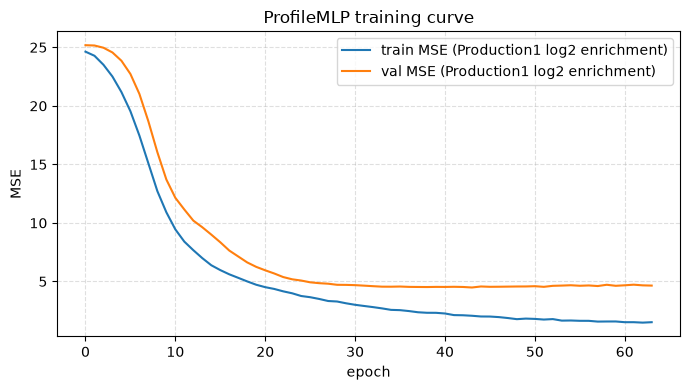

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_mlp["train_loss"], label="train MSE (Production1 log2 enrichment)")
ax.plot(hist_mlp["val_loss"],   label="val MSE (Production1 log2 enrichment)")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE")
ax.set_title("ProfileMLP training curve")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

## 5. Test on the held-out 80%, against their Production2 log2 enrichment

`r_replicate_ceiling` (Pearson r between `log2(Production1)` and `log2(Production2)` on
these same held-out variants) is the reproducibility ceiling from
`log_enrichment_histograms.ipynb`, restricted to this test split -- the model can't be
expected to beat how well the two real replicates agree with each other.

Pearson r (train, vs Production1):            0.9758
Pearson r (test, MLP vs Production2):          0.8265
Pearson r (replicate ceiling, Production1 vs Production2, same test rows): 0.8915

Held-out (test) top-k recovery, vs Production2:
  Top   1%   precision = 0.106   (random baseline = 0.010)
  Top   5%   precision = 0.283   (random baseline = 0.050)
  Top  10%   precision = 0.419   (random baseline = 0.100)
  Top  20%   precision = 0.595   (random baseline = 0.200)


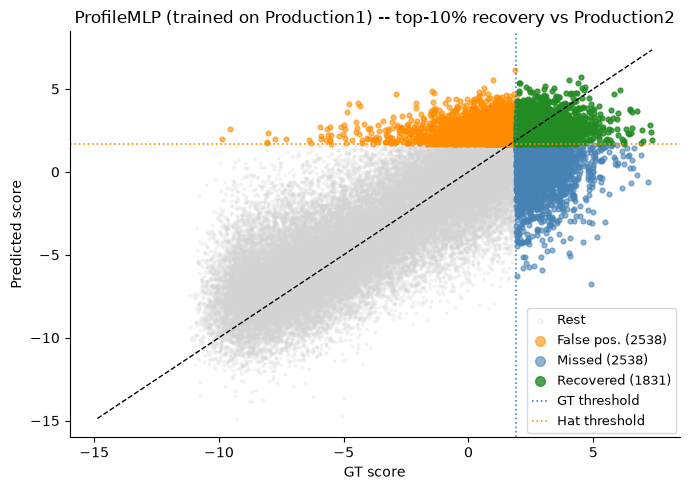

In [7]:
@nnx.jit
def predict_scores(model, x):
    return model(x, train=False)

pred_train = np.asarray(predict_scores(model_mlp, jnp.asarray(Xtr)))
pred_test  = np.asarray(predict_scores(model_mlp, jnp.asarray(X_test)))

r_train             = pearson(ytr, pred_train)
r_test_vs_prod2      = pearson(y_test, pred_test)
r_replicate_ceiling  = pearson(log2_p1[idx_test], log2_p2[idx_test])

print(f"Pearson r (train, vs Production1):            {r_train:.4f}")
print(f"Pearson r (test, MLP vs Production2):          {r_test_vs_prod2:.4f}")
print(f"Pearson r (replicate ceiling, Production1 vs Production2, same test rows): {r_replicate_ceiling:.4f}")
print()
print("Held-out (test) top-k recovery, vs Production2:")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_test, pred_test, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_test, pred_test, k_frac=0.10,
                          title="ProfileMLP (trained on Production1) -- top-10% recovery vs Production2")
plt.show()

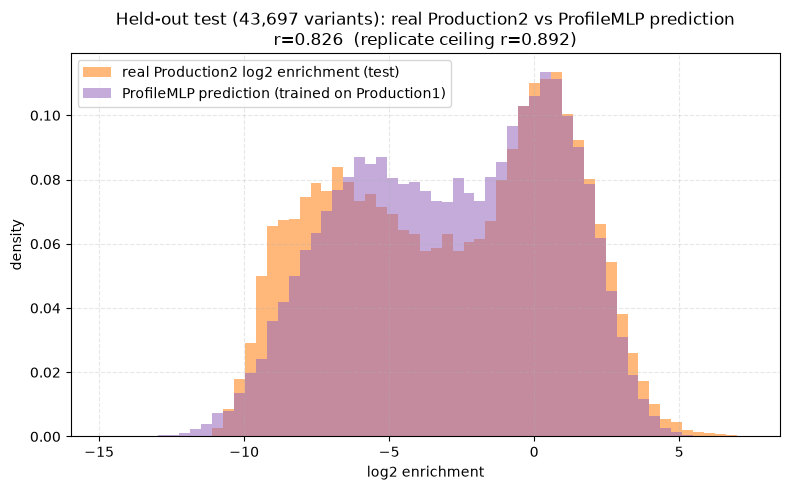

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max()), 60)
ax.hist(y_test,    bins=bins, alpha=0.55, density=True, color="tab:orange", label="real Production2 log2 enrichment (test)")
ax.hist(pred_test, bins=bins, alpha=0.55, density=True, color="tab:purple", label="ProfileMLP prediction (trained on Production1)")
ax.set_xlabel("log2 enrichment")
ax.set_ylabel("density")
ax.set_title(f"Held-out test ({len(y_test):,} variants): real Production2 vs ProfileMLP prediction\n"
             f"r={r_test_vs_prod2:.3f}  (replicate ceiling r={r_replicate_ceiling:.3f})")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()